In [34]:
# loads required imports (Polars-first)
import os
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from data_integration import combine_data, read_data

try:
    from scipy.stats import kendalltau
except Exception:
    kendalltau = None


In [35]:
# reads and integrates available datasets
restricted_list = read_data(read_all=False)

dataset_root = globals().get("dataset_root")
gap_label_order = ["<30 min", "30 min-1 h", "1-2 h", "2-4 h", "4-24 h", ">24 h"]

def resolve_dataset_file(filename: str) -> str:
    global dataset_root
    candidate_roots = []
    if dataset_root:
        candidate_roots.append(dataset_root)
    candidate_roots.extend([
        os.path.join("datasets for T1D"),
        os.path.join("DiaData", "datasets for T1D"),
    ])

    for root in candidate_roots:
        path = os.path.join(root, filename)
        if os.path.exists(path):
            dataset_root = root
            return path

    raise FileNotFoundError(
        f"Could not find '{filename}'. Place it in 'datasets for T1D'."
    )


def safe_combine_data(modus: int, schema_cols: list[str]) -> pl.DataFrame:
    try:
        df = combine_data(modus, restricted_list)
        if df is None:
            return pl.DataFrame({c: [] for c in schema_cols})
        pldf = pl.from_pandas(df)
        for col in schema_cols:
            if col not in pldf.columns:
                pldf = pldf.with_columns(pl.lit(None).alias(col))
        return pldf.select(schema_cols)
    except Exception:
        return pl.DataFrame({c: [] for c in schema_cols})


def millions(x, pos):
    return f"{x * 1e-6:.2f} Mio".rstrip("0").rstrip(".")


def get_lower_bound(range_str: str) -> int:
    text = str(range_str).strip()
    if "-" in text:
        return int(text.split("-")[0])
    return int(text.split("+")[0])


def boxplot_by_category(df: pl.DataFrame, value_col: str, cat_col: str, title: str, ylabel: str, ordered_categories: list[str] | None = None):
    local = df.drop_nulls([value_col, cat_col]).with_columns(pl.col(cat_col).cast(pl.Utf8))
    if local.is_empty():  
        print(f"No data available for {title}")
        return

    categories = ordered_categories or local.select(cat_col).unique().sort(cat_col).get_column(cat_col).to_list()
    values = []
    labels = []
    for cat in categories:
        arr = local.filter(pl.col(cat_col) == cat).get_column(value_col).to_numpy()
        if arr.size > 0:
            values.append(arr)
            labels.append(cat)

    if not values:
        print(f"No plottable data for {title}")
        return

    plt.figure(figsize=(8, 6))
    plt.boxplot(values, labels=labels, showmeans=True)
    plt.title(title)
    plt.xlabel(cat_col)
    plt.ylabel(ylabel)
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()


def compute_missing_gaps(df: pl.DataFrame, value_col: str) -> pl.DataFrame:
    if df.is_empty():
        return pl.DataFrame({"MissingGroup": [], "missing_count_time": [], "count": []})

    base = (
        df.select(["PtID", "ts", value_col])
        .sort(["PtID", "ts"])
        .with_columns(
            pl.col(value_col).is_null().alias("missing")
        )
        .with_columns(
            (
                (
                    pl.col("missing")
                    != pl.col("missing").shift(1).over("PtID")
                )
                .fill_null(True)
                .cast(pl.Int64)
                .cum_sum()
                .over("PtID")
            ).alias("gap_id")
        )
    )

    gaps = (
        base.filter(pl.col("missing"))
        .group_by(["PtID", "gap_id"])
        .len()
        .rename({"len": "missing_count"})
        .with_columns((pl.col("missing_count") * 5).alias("missing_count_time"))
    )

    if gaps.is_empty():
        return pl.DataFrame({"MissingGroup": [], "missing_count_time": [], "count": []})

    gaps = gaps.with_columns(
        pl.when(pl.col("missing_count_time") < 30)
        .then(pl.lit("<30 min"))
        .when(pl.col("missing_count_time") < 60)
        .then(pl.lit("30 min-1 h"))
        .when(pl.col("missing_count_time") < 120)
        .then(pl.lit("1-2 h"))
        .when(pl.col("missing_count_time") < 240)
        .then(pl.lit("2-4 h"))
        .when(pl.col("missing_count_time") < 1440)
        .then(pl.lit("4-24 h"))
        .otherwise(pl.lit(">24 h"))
        .alias("MissingGroup")
    )

    return gaps


Error in df_granada(): [Errno 2] No such file or directory: 'datasets for T1D/granada/T1DiabetesGranada/glucose_measurements.csv'
Error in df_diatrend(): No objects to concatenate


## Read the dataframes

In [36]:
# loads the main dataset with CGM measurements
#DATA_MODE = ""  # choose: "tiny", "half", 
DATA_MODE = "tiny"  # choose: "tiny", "half", "full"
if DATA_MODE == "full":
    preferred = ["maindatabase.csv"]
elif DATA_MODE == "half":
    preferred = ["maindatabase_half.csv", "maindatabase_sample.csv", "maindatabase.csv"]
else:
    preferred = ["maindatabase_sample.csv", "maindatabase_half.csv", "maindatabase.csv"]

main_path = None
for fname in preferred:
    try:
        main_path = resolve_dataset_file(fname)
        break
    except FileNotFoundError:
        continue

if main_path is None:
    raise FileNotFoundError("No main database file found in datasets for T1D.")

combined_main_public = (
    pl.scan_csv(main_path, ignore_errors=True)
    .select(["ts", "PtID", "GlucoseCGM", "Database"])
    .with_columns(
        [
            pl.col("ts").str.to_datetime(strict=False).alias("ts"),
            pl.col("PtID").cast(pl.Utf8),
            pl.col("GlucoseCGM").cast(pl.Float32),
            pl.col("Database").cast(pl.Utf8),
        ]
    )
    .drop_nulls(["ts", "PtID"])
    .collect(engine="streaming")
)

combined_main_restricted = safe_combine_data(1, ["ts", "PtID", "GlucoseCGM", "Database"]).with_columns(
    [
        pl.col("ts").cast(pl.Datetime, strict=False),
        pl.col("PtID").cast(pl.Utf8),
        pl.col("GlucoseCGM").cast(pl.Float32, strict=False),
        pl.col("Database").cast(pl.Utf8),
    ]
)

combined_main = (
    pl.concat([combined_main_restricted, combined_main_public], how="vertical_relaxed")
    .sort(["PtID", "ts"])
    .unique(subset=["PtID", "ts"], keep="first", maintain_order=True)
)

print(f"Loaded main file: {main_path}")
print(f"combined_main rows: {combined_main.height:,}")


Loaded main file: datasets for T1D\maindatabase_sample.csv
combined_main rows: 9,999


In [37]:
# load subdatabase I with CGM + demographics (restricted integration)
combined_subI = safe_combine_data(2, ["ts", "PtID", "GlucoseCGM", "Age", "Sex", "Database", "AgeGroup"]).with_columns(
    [
        pl.col("ts").cast(pl.Datetime, strict=False),
        pl.col("PtID").cast(pl.Utf8),
        pl.col("GlucoseCGM").cast(pl.Float32, strict=False),
        pl.col("Database").cast(pl.Utf8),
    ]
)

print(f"combined_subI rows: {combined_subI.height:,}")
print(f"combined_subI columns: {combined_subI.columns}")


combined_subI rows: 0
combined_subI columns: ['ts', 'PtID', 'GlucoseCGM', 'Age', 'Sex', 'Database', 'AgeGroup']


In [38]:
# load subdatabase II with CGM + HR
try:
    subII_path = resolve_dataset_file("subdatabaseII.csv")
    combined_subII = (
        pl.scan_csv(subII_path, ignore_errors=True)
        .with_columns(
            [
                pl.col("ts").str.to_datetime(strict=False).alias("ts"),
                pl.col("PtID").cast(pl.Utf8),
                pl.col("GlucoseCGM").cast(pl.Float32, strict=False),
                pl.col("HR").cast(pl.Float32, strict=False),
            ]
        )
        .drop_nulls(["ts", "PtID"])
        .collect(engine="streaming")
    )
except FileNotFoundError:
    combined_subII = safe_combine_data(3, ["ts", "PtID", "GlucoseCGM", "HR", "Database"]).with_columns(
        [
            pl.col("ts").cast(pl.Datetime, strict=False),
            pl.col("PtID").cast(pl.Utf8),
            pl.col("GlucoseCGM").cast(pl.Float32, strict=False),
            pl.col("HR").cast(pl.Float32, strict=False),
        ]
    )

combined_subII = combined_subII.sort(["PtID", "ts"])
print(f"combined_subII rows: {combined_subII.height:,}")


combined_subII rows: 0


## Plotting Figures

### Glucose Characteristics

Plots the distribution of glucose characteristics and boxplots for each single database 

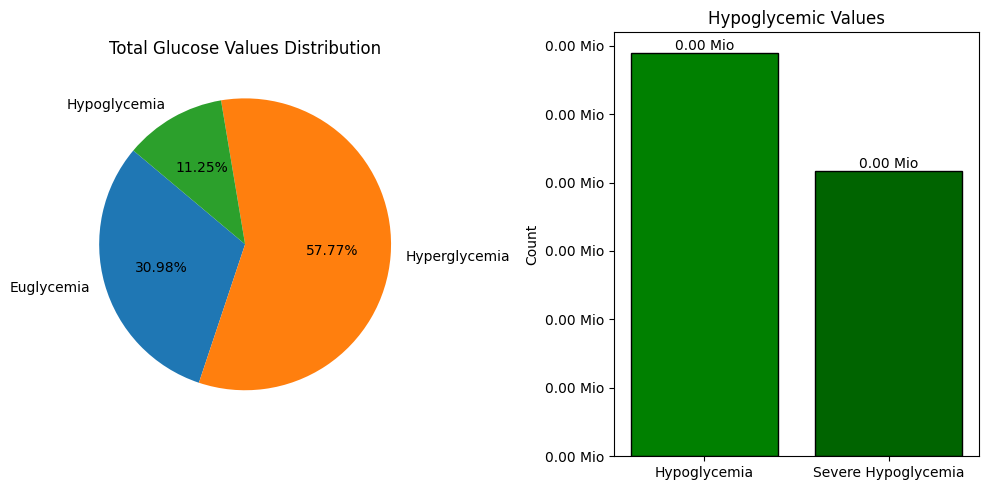

In [39]:
# plots the distribution of glucose characteristics
combined_df_glc_filtered = combined_main.drop_nulls("GlucoseCGM")

combined_df_glc_filtered = combined_df_glc_filtered.with_columns(
    pl.when(pl.col("GlucoseCGM") <= 70)
    .then(pl.lit("Hypoglycemia"))
    .when(pl.col("GlucoseCGM") >= 180)
    .then(pl.lit("Hyperglycemia"))
    .otherwise(pl.lit("Euglycemia"))
    .alias("GLCRange")
)

combined_plus_sever = combined_df_glc_filtered.with_columns(
    pl.when(pl.col("GlucoseCGM") <= 54)
    .then(pl.lit("Severe Hypoglycemia"))
    .otherwise(pl.col("GLCRange"))
    .alias("GLCRange")
)

glucose_char_counts = (
    combined_df_glc_filtered
    .group_by("GLCRange")
    .len()
    .sort("GLCRange")
)

glucose_hypo_counts = (
    combined_plus_sever
    .filter(pl.col("GLCRange").is_in(["Hypoglycemia", "Severe Hypoglycemia"]))
    .group_by("GLCRange")
    .len()
    .sort("GLCRange")
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.pie(
    glucose_char_counts.get_column("len").to_list(),
    labels=glucose_char_counts.get_column("GLCRange").to_list(),
    autopct="%1.2f%%",
    startangle=140,
)
ax1.set_title("Total Glucose Values Distribution")

ax2.bar(
    glucose_hypo_counts.get_column("GLCRange").to_list(),
    glucose_hypo_counts.get_column("len").to_list(),
    width=0.8,
    edgecolor="black",
    color=["green", "darkgreen"],
)
ax2.set_title("Hypoglycemic Values")
ax2.set_ylabel("Count")
ax2.yaxis.set_major_formatter(FuncFormatter(millions))

for bar in ax2.patches:
    h = bar.get_height()
    label = f"{h / 1e6:.2f} Mio".rstrip("0").rstrip(".")
    ax2.text(bar.get_x() + bar.get_width() / 2, h, label, ha="center", va="bottom")

plt.tight_layout()
plt.show()


C:\Users\shree\AppData\Local\Temp\ipykernel_18712\2391878573.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showmeans=True)


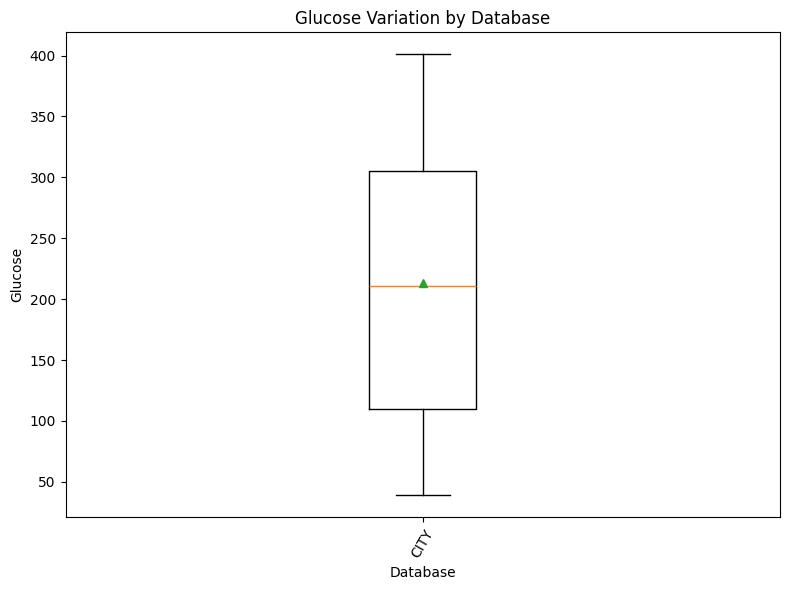

In [40]:
# plots boxplot of glucose values by database
boxplot_by_category(
    df=combined_main,
    value_col="GlucoseCGM",
    cat_col="Database",
    title="Glucose Variation by Database",
    ylabel="Glucose",
)


### Exploring Missing Values 

Plots the missing values count distribution of the main database and also the total number of missing values per single database

C:\Users\shree\AppData\Local\Temp\ipykernel_18712\1003821506.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=60)


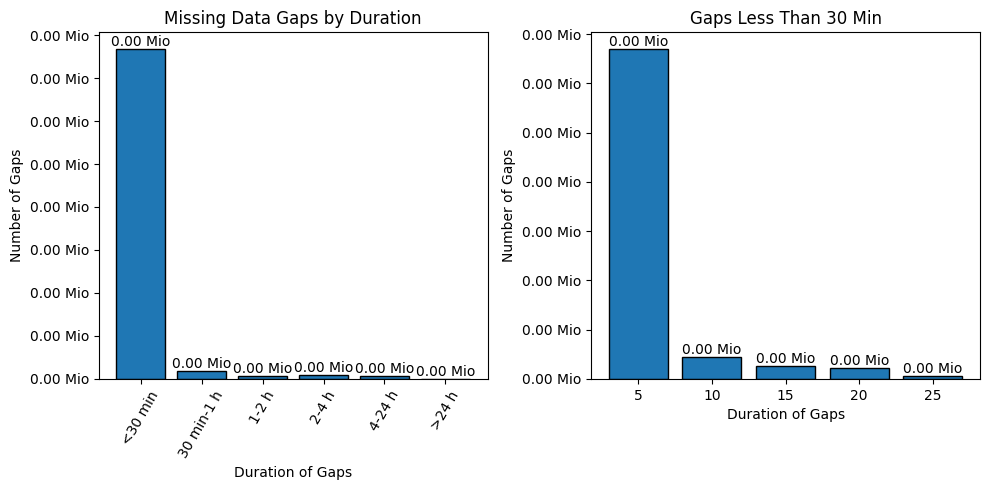

In [41]:
# plots missing-value gaps of glucose
na_groups = compute_missing_gaps(combined_main, "GlucoseCGM")

if na_groups.is_empty():
    print("No missing glucose gaps found.")
else:
    gap_counts = (
        na_groups
        .group_by("MissingGroup")
        .len()
        .rename({"len": "count"})
    )
    gap_counts = pl.DataFrame({"MissingGroup": gap_label_order}).join(gap_counts, on="MissingGroup", how="left").fill_null(0)

    count_30_missing = (
        na_groups
        .filter(pl.col("MissingGroup") == "<30 min")
        .group_by("missing_count_time")
        .len()
        .rename({"len": "count"})
        .sort("missing_count_time")
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.bar(
        gap_counts.get_column("MissingGroup").to_list(),
        gap_counts.get_column("count").to_list(),
        edgecolor="black",
    )
    ax1.set_title("Missing Data Gaps by Duration")
    ax1.set_xlabel("Duration of Gaps")
    ax1.set_ylabel("Number of Gaps")
    ax1.yaxis.set_major_formatter(FuncFormatter(millions))
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=60)

    for bar in ax1.patches:
        h = bar.get_height()
        label = f"{h / 1e6:.2f} Mio".rstrip("0").rstrip(".")
        ax1.text(bar.get_x() + bar.get_width() / 2, h, label, ha="center", va="bottom")

    ax2.bar(
        count_30_missing.get_column("missing_count_time").cast(pl.Utf8).to_list(),
        count_30_missing.get_column("count").to_list(),
        width=0.8,
        edgecolor="black",
    )
    ax2.set_title("Gaps Less Than 30 Min")
    ax2.set_xlabel("Duration of Gaps")
    ax2.set_ylabel("Number of Gaps")
    ax2.yaxis.set_major_formatter(FuncFormatter(millions))

    for bar in ax2.patches:
        h = bar.get_height()
        label = f"{h / 1e6:.2f} Mio".rstrip("0").rstrip(".")
        ax2.text(bar.get_x() + bar.get_width() / 2, h, label, ha="center", va="bottom")

    plt.tight_layout()
    plt.show()


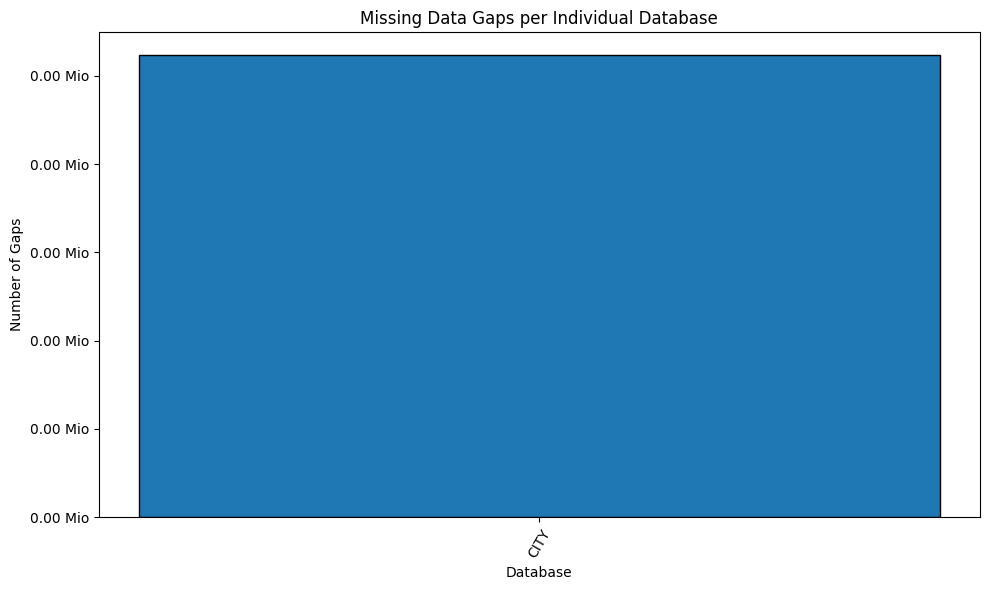

In [42]:
# plots missing values per single database
if combined_main.is_empty():
    print("combined_main is empty")
else:
    df_missing_counts = (
        combined_main
        .group_by("Database")
        .agg(pl.col("GlucoseCGM").is_null().sum().alias("missing_count"))
        .sort("Database")
    )

    plt.figure(figsize=(10, 6))
    plt.bar(
        df_missing_counts.get_column("Database").to_list(),
        df_missing_counts.get_column("missing_count").to_list(),
        edgecolor="black",
    )
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
    plt.xticks(rotation=60)
    plt.title("Missing Data Gaps per Individual Database")
    plt.xlabel("Database")
    plt.ylabel("Number of Gaps")
    plt.tight_layout()
    plt.show()


### Analysis of Demographics

Plots the distribution of demographics (age and sex) of subdatabase II 

In [43]:
# helper to sort age-range labels
# returns the lower boundary of age bins like '18-25' or '56+'
def get_lower_bound(range_str: str) -> int:
    text = str(range_str).strip()
    if "-" in text:
        return int(text.split("-")[0])
    return int(text.split("+")[0])


In [44]:
# plots distribution of age groups across Subdataset I (subjects)
if combined_subI.is_empty() or "AgeGroup" not in combined_subI.columns:
    print("AgeGroup data is not available in combined_subI.")
else:
    df_demo_only_ages = (
        combined_subI
        .drop_nulls(["PtID", "AgeGroup"])
        .select(["PtID", "AgeGroup"])
        .unique(subset=["PtID"])
    )

    age_counts = (
        df_demo_only_ages
        .group_by("AgeGroup")
        .len()
        .rename({"len": "count"})
        .with_columns(
            pl.col("AgeGroup")
            .cast(pl.Utf8)
            .map_elements(get_lower_bound, return_dtype=pl.Int64)
            .alias("lower_bound")
        )
        .sort("lower_bound")
    )

    total = max(1, age_counts.get_column("count").sum())
    percentages = (age_counts.get_column("count") / total * 100).round(1)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        age_counts.get_column("AgeGroup").cast(pl.Utf8).to_list(),
        age_counts.get_column("count").to_list(),
        width=0.8,
        edgecolor="black",
    )
    plt.title("Distribution of Age Groups Across the Dataset")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Subjects")

    for bar, pct in zip(bars, percentages.to_list()):
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{pct}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


AgeGroup data is not available in combined_subI.


In [45]:
# plots distribution of glucose measurements per age group
if combined_subI.is_empty() or "AgeGroup" not in combined_subI.columns:
    print("AgeGroup data is not available in combined_subI.")
else:
    combined_subI2_filtered = combined_subI.drop_nulls(["GlucoseCGM", "AgeGroup"])

    glucoseage_counts = (
        combined_subI2_filtered
        .group_by("AgeGroup")
        .len()
        .rename({"len": "count"})
        .with_columns(
            pl.col("AgeGroup")
            .cast(pl.Utf8)
            .map_elements(get_lower_bound, return_dtype=pl.Int64)
            .alias("lower_bound")
        )
        .sort("lower_bound")
    )

    total = max(1, glucoseage_counts.get_column("count").sum())
    percentages = (glucoseage_counts.get_column("count") / total * 100).round(1)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        glucoseage_counts.get_column("AgeGroup").cast(pl.Utf8).to_list(),
        glucoseage_counts.get_column("count").to_list(),
        width=0.8,
        edgecolor="black",
    )
    plt.title("Measurement Frequency by Age Groups")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Glucose Measurements")

    for bar, pct in zip(bars, percentages.to_list()):
        h = bar.get_height()
        if h > 0:
            plt.text(bar.get_x() + bar.get_width() / 2, h + 1, f"{pct}%", ha="center", va="bottom", fontsize=9)

    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
    plt.tight_layout()
    plt.show()


AgeGroup data is not available in combined_subI.


In [46]:
# plots distribution of sex across Subdatabase I (subjects)
if combined_subI.is_empty() or "Sex" not in combined_subI.columns:
    print("Sex data is not available in combined_subI.")
else:
    df_demo_only_sex = (
        combined_subI
        .drop_nulls(["PtID", "Sex"])
        .select(["PtID", "Sex"])
        .unique(subset=["PtID"])
    )

    gender_counts = df_demo_only_sex.group_by("Sex").len().sort("Sex")
    labels = [f"{s} ({c})" for s, c in zip(gender_counts.get_column("Sex").to_list(), gender_counts.get_column("len").to_list())]

    plt.figure(figsize=(6, 6))
    plt.pie(gender_counts.get_column("len").to_list(), labels=labels, autopct="%1.2f%%", startangle=140, colors=["orchid", "steelblue"])
    plt.title("Sex Distribution")
    plt.axis("equal")
    plt.show()


Sex data is not available in combined_subI.


In [47]:
# plots glucose value count per sex
if combined_subI.is_empty() or "Sex" not in combined_subI.columns:
    print("Sex data is not available in combined_subI.")
else:
    combined_subI2_filtered = combined_subI.drop_nulls(["GlucoseCGM", "Sex"])
    glucosegender_counts = combined_subI2_filtered.group_by("Sex").len().sort("Sex")

    plt.figure(figsize=(6, 6))
    plt.pie(
        glucosegender_counts.get_column("len").to_list(),
        labels=glucosegender_counts.get_column("Sex").to_list(),
        autopct="%1.2f%%",
        startangle=140,
        colors=["orchid", "steelblue"],
    )
    plt.title("Glucose Values per Sex")
    plt.axis("equal")
    plt.show()


Sex data is not available in combined_subI.


In [48]:
# plots subject sex count by age group
if combined_subI.is_empty() or not {"AgeGroup", "Sex"}.issubset(set(combined_subI.columns)):
    print("AgeGroup/Sex data is not available in combined_subI.")
else:
    df_demo_only = (
        combined_subI
        .drop_nulls(["PtID", "AgeGroup", "Sex"])
        .select(["PtID", "AgeGroup", "Sex"])
        .unique(subset=["PtID"])
    )

    counts = (
        df_demo_only
        .group_by(["AgeGroup", "Sex"])
        .len()
        .pivot(values="len", index="AgeGroup", on="Sex")
        .fill_null(0)
        .with_columns(
            pl.col("AgeGroup")
            .cast(pl.Utf8)
            .map_elements(get_lower_bound, return_dtype=pl.Int64)
            .alias("lower_bound")
        )
        .sort("lower_bound")
    )

    age_groups = counts.get_column("AgeGroup").cast(pl.Utf8).to_list()
    f_vals = counts.get_column("F").to_list() if "F" in counts.columns else [0] * len(age_groups)
    m_vals = counts.get_column("M").to_list() if "M" in counts.columns else [0] * len(age_groups)

    x = np.arange(len(age_groups))
    width = 0.4
    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, f_vals, width=width, color="orchid", edgecolor="black", label="F")
    plt.bar(x + width / 2, m_vals, width=width, color="steelblue", edgecolor="black", label="M")
    plt.xticks(x, age_groups)
    plt.title("Sex Count by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Subjects")
    plt.legend(title="Sex")
    plt.tight_layout()
    plt.show()


AgeGroup/Sex data is not available in combined_subI.


In [49]:
# plots glucose measurement frequency by age group and sex
if combined_subI.is_empty() or not {"AgeGroup", "Sex", "GlucoseCGM"}.issubset(set(combined_subI.columns)):
    print("AgeGroup/Sex/GlucoseCGM data is not available in combined_subI.")
else:
    combined_subI2_filtered = combined_subI.drop_nulls(["GlucoseCGM", "AgeGroup", "Sex"])

    counts_demo = (
        combined_subI2_filtered
        .group_by(["AgeGroup", "Sex"])
        .len()
        .pivot(values="len", index="AgeGroup", on="Sex")
        .fill_null(0)
        .with_columns(
            pl.col("AgeGroup")
            .cast(pl.Utf8)
            .map_elements(get_lower_bound, return_dtype=pl.Int64)
            .alias("lower_bound")
        )
        .sort("lower_bound")
    )

    age_groups = counts_demo.get_column("AgeGroup").cast(pl.Utf8).to_list()
    f_vals = counts_demo.get_column("F").to_list() if "F" in counts_demo.columns else [0] * len(age_groups)
    m_vals = counts_demo.get_column("M").to_list() if "M" in counts_demo.columns else [0] * len(age_groups)

    x = np.arange(len(age_groups))
    width = 0.4
    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, f_vals, width=width, color="orchid", edgecolor="black", label="F")
    plt.bar(x + width / 2, m_vals, width=width, color="steelblue", edgecolor="black", label="M")
    plt.xticks(x, age_groups)
    plt.title("Measurement Frequency by Age Groups and Sex")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Glucose Measurements")
    plt.legend(title="Sex", loc="upper left")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
    plt.tight_layout()
    plt.show()


AgeGroup/Sex/GlucoseCGM data is not available in combined_subI.


In [50]:
# plots boxplot of glucose variation across age groups
if combined_subI.is_empty() or not {"AgeGroup", "GlucoseCGM"}.issubset(set(combined_subI.columns)):
    print("AgeGroup/GlucoseCGM data is not available in combined_subI.")
else:
    age_order_df = (
        combined_subI
        .drop_nulls(["AgeGroup"])
        .select("AgeGroup")
        .unique()
        .with_columns(
            pl.col("AgeGroup")
            .cast(pl.Utf8)
            .map_elements(get_lower_bound, return_dtype=pl.Int64)
            .alias("lower_bound")
        )
        .sort("lower_bound")
    )
    age_order = age_order_df.get_column("AgeGroup").cast(pl.Utf8).to_list()

    boxplot_by_category(
        df=combined_subI,
        value_col="GlucoseCGM",
        cat_col="AgeGroup",
        title="Variation of Glucose Levels by Age Group",
        ylabel="Glucose Levels",
        ordered_categories=age_order,
    )


AgeGroup/GlucoseCGM data is not available in combined_subI.


In [51]:
# plots boxplot of glucose variation by sex
if combined_subI.is_empty() or not {"Sex", "GlucoseCGM"}.issubset(set(combined_subI.columns)):
    print("Sex/GlucoseCGM data is not available in combined_subI.")
else:
    boxplot_by_category(
        df=combined_subI,
        value_col="GlucoseCGM",
        cat_col="Sex",
        title="Variation of Glucose Levels by Sex",
        ylabel="Glucose Levels",
    )


Sex/GlucoseCGM data is not available in combined_subI.


### Heart-rate Analysis

In [52]:
# plots boxplot for heartrate variation across databases
if combined_subII.is_empty() or not {"HR", "Database"}.issubset(set(combined_subII.columns)):
    print("HR/Database data is not available in combined_subII.")
else:
    boxplot_by_category(
        df=combined_subII,
        value_col="HR",
        cat_col="Database",
        title="Heart-rate Variation by Database",
        ylabel="Heart-rate",
    )


HR/Database data is not available in combined_subII.


In [53]:
# plots missing-value gaps for heart-rate
if combined_subII.is_empty() or "HR" not in combined_subII.columns:
    print("HR data is not available in combined_subII.")
else:
    na_groups = compute_missing_gaps(combined_subII, "HR")

    if na_groups.is_empty():
        print("No missing HR gaps found.")
    else:
        gap_counts = (
            na_groups
            .group_by("MissingGroup")
            .len()
            .rename({"len": "count"})
        )
        gap_counts = pl.DataFrame({"MissingGroup": gap_label_order}).join(gap_counts, on="MissingGroup", how="left").fill_null(0)

        count_30_missing = (
            na_groups
            .filter(pl.col("MissingGroup") == "<30 min")
            .group_by("missing_count_time")
            .len()
            .rename({"len": "count"})
            .sort("missing_count_time")
        )

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        ax1.bar(
            gap_counts.get_column("MissingGroup").to_list(),
            gap_counts.get_column("count").to_list(),
            edgecolor="black",
        )
        ax1.set_title("Missing Data Gaps by Duration for Heart-rate")
        ax1.set_xlabel("Duration of Gaps")
        ax1.set_ylabel("Number of Gaps")
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=60)

        for bar in ax1.patches:
            h = bar.get_height()
            label = f"{h:.0f}"
            ax1.text(bar.get_x() + bar.get_width() / 2, h, label, ha="center", va="bottom")

        ax2.bar(
            count_30_missing.get_column("missing_count_time").cast(pl.Utf8).to_list(),
            count_30_missing.get_column("count").to_list(),
            width=0.8,
            edgecolor="black",
        )
        ax2.set_title("Gaps Less Than 30 Min")
        ax2.set_xlabel("Duration of Gaps")
        ax2.set_ylabel("Number of Gaps")

        for bar in ax2.patches:
            h = bar.get_height()
            label = f"{h:.0f}"
            ax2.text(bar.get_x() + bar.get_width() / 2, h, label, ha="center", va="bottom")

        plt.tight_layout()
        plt.show()


HR data is not available in combined_subII.


In [54]:
# assign classes for pre-hypoglycemia windows and define correlation helpers

def class_generation(group: pl.DataFrame, timestamp_col: str, start: int, end: int, class_number: int) -> pl.DataFrame:
    local = group.sort(timestamp_col)
    ts = local.get_column(timestamp_col).to_numpy()
    classes = local.get_column("Class").to_numpy().copy()

    event_indices = np.where(classes == 0)[0]
    for idx in event_indices:
        start_time = ts[idx] - np.timedelta64(start, "m")
        end_time = ts[idx] - np.timedelta64(end, "m")
        mask = (ts > end_time) & (ts <= start_time) & (classes == -1)
        classes[mask] = class_number

    return local.with_columns(pl.Series("Class", classes))


def corr_triplet(df: pl.DataFrame, x_col: str = "GlucoseCGM", y_col: str = "HR") -> tuple[float, float, float]:
    pair = df.select([x_col, y_col]).drop_nulls()
    if pair.height < 3:
        return np.nan, np.nan, np.nan

    x = pair.get_column(x_col).to_numpy()
    y = pair.get_column(y_col).to_numpy()

    pearson = float(np.corrcoef(x, y)[0, 1])

    x_rank = pl.Series(x).rank(method="average").to_numpy()
    y_rank = pl.Series(y).rank(method="average").to_numpy()
    spearman = float(np.corrcoef(x_rank, y_rank)[0, 1])

    if kendalltau is not None:
        kendall = float(kendalltau(x, y, nan_policy="omit").statistic)
    else:
        kendall = np.nan

    return pearson, spearman, kendall


if combined_subII.is_empty() or not {"PtID", "ts", "GlucoseCGM", "HR"}.issubset(set(combined_subII.columns)):
    classes_df = pl.DataFrame({"PtID": [], "ts": [], "GlucoseCGM": [], "HR": [], "Class": []})
    print("Subdatabase II is missing required columns for class generation.")
else:
    classes_df = (
        combined_subII
        .select(["PtID", "ts", "GlucoseCGM", "HR", "Database"])
        .with_columns(
            pl.when(pl.col("GlucoseCGM") <= 70)
            .then(pl.lit(0))
            .otherwise(pl.lit(-1))
            .alias("Class")
        )
        .sort(["PtID", "ts"])
    )

    updated_groups = []
    for group in classes_df.partition_by("PtID", maintain_order=True):
        g = group
        g = class_generation(g, "ts", 5, 15, 1)
        g = class_generation(g, "ts", 15, 30, 2)
        g = class_generation(g, "ts", 30, 60, 3)
        g = class_generation(g, "ts", 60, 125, 4)
        g = g.with_columns(pl.when(pl.col("Class") == -1).then(pl.lit(5)).otherwise(pl.col("Class")).alias("Class"))
        updated_groups.append(g)

    classes_df = pl.concat(updated_groups, how="vertical_relaxed").sort(["PtID", "ts"])

print({
    "rows": classes_df.height,
    "class_counts": (
        classes_df.group_by("Class").len().sort("Class").to_dict(as_series=False)
        if classes_df.height > 0 else {}
    ),
})


Subdatabase II is missing required columns for class generation.
{'rows': 0, 'class_counts': {}}


In [55]:
# computes population correlations for all values
if classes_df.is_empty():
    print("classes_df is empty")
else:
    pearson_corr, spearman_corr, kendall_corr = corr_triplet(classes_df)
    print(f"Pearson correlation: {pearson_corr:.6f}")
    print(f"Spearman correlation: {spearman_corr:.6f}")
    if np.isnan(kendall_corr):
        print("Kendall correlation: NaN (install scipy for exact Kendall tau)")
    else:
        print(f"Kendall correlation: {kendall_corr:.6f}")


classes_df is empty


In [56]:
# computes mean correlations across subjects
if classes_df.is_empty():
    print("classes_df is empty")
else:
    per_subject = []
    for group in classes_df.partition_by("PtID", maintain_order=True):
        p, s, k = corr_triplet(group)
        per_subject.append((p, s, k))

    per_subject = np.array(per_subject, dtype=float)
    print(f"Mean pearson correlation across patients: {np.nanmean(per_subject[:, 0]):.4f}")
    print(f"Mean spearman correlation across patients: {np.nanmean(per_subject[:, 1]):.4f}")
    print(f"Mean kendall correlation across patients: {np.nanmean(per_subject[:, 2]):.4f}")


classes_df is empty


In [57]:
# computes pearson correlation by class
pearson_by_class = {}
if classes_df.is_empty():
    print("classes_df is empty")
else:
    classes_sorted = classes_df.select("Class").unique().sort("Class").get_column("Class").to_list()
    for class_id in classes_sorted:
        subset = classes_df.filter(pl.col("Class") == class_id)
        p, _, _ = corr_triplet(subset)
        pearson_by_class[int(class_id)] = p
    print(pearson_by_class)


classes_df is empty


In [58]:
# computes spearman correlation by class
spearman_by_class = {}
if classes_df.is_empty():
    print("classes_df is empty")
else:
    classes_sorted = classes_df.select("Class").unique().sort("Class").get_column("Class").to_list()
    for class_id in classes_sorted:
        subset = classes_df.filter(pl.col("Class") == class_id)
        _, s, _ = corr_triplet(subset)
        spearman_by_class[int(class_id)] = s
    print(spearman_by_class)


classes_df is empty


In [59]:
# computes kendall correlation by class
kendall_by_class = {}
if classes_df.is_empty():
    print("classes_df is empty")
else:
    classes_sorted = classes_df.select("Class").unique().sort("Class").get_column("Class").to_list()
    for class_id in classes_sorted:
        subset = classes_df.filter(pl.col("Class") == class_id)
        _, _, k = corr_triplet(subset)
        kendall_by_class[int(class_id)] = k
    print(kendall_by_class)


classes_df is empty


In [60]:
# plots correlation scores per class
if not pearson_by_class:
    print("No class-wise correlations available.")
else:
    classes_sorted = sorted(pearson_by_class.keys())
    pearson_vals = [pearson_by_class.get(c, np.nan) for c in classes_sorted]
    spearman_vals = [spearman_by_class.get(c, np.nan) for c in classes_sorted]
    kendall_vals = [kendall_by_class.get(c, np.nan) for c in classes_sorted]

    plt.figure(figsize=(10, 6))
    plt.plot(classes_sorted, kendall_vals, marker="o", label="Kendall")
    plt.plot(classes_sorted, spearman_vals, marker="o", label="Spearman")
    plt.plot(classes_sorted, pearson_vals, marker="o", label="Pearson")
    plt.title("Correlation Scores per Class Between Heartrate and CGM Values")
    plt.xlabel("Class")
    plt.ylabel("Correlation")
    plt.legend()
    plt.tight_layout()
    plt.show()


No class-wise correlations available.


## LSTM Model (Polars-first)

This section runs a full LSTM hypoglycemia prediction pipeline using **Polars** for preprocessing and sequence creation.


In [66]:
# Polars-first LSTM pipeline imports
from pathlib import Path
import json

from lstm_polars import TrainConfig, run_training

# Use notebook-selected file when available
if 'main_path' in globals() and main_path:
    data_path = Path(main_path)
else:
    dataset_candidates = [
        Path('datasets for T1D/maindatabase_sample.csv'),
        Path('datasets for T1D/maindatabase_half.csv'),
        Path('datasets for T1D/maindatabase.csv'),
    ]
    data_path = None
    for candidate in dataset_candidates:
        if candidate.exists():
            data_path = candidate
            break

if data_path is None:
    raise FileNotFoundError('No maindatabase CSV found in datasets for T1D.')

# Set to True only when you want full model training from notebook
RUN_LSTM = True 
print(f'Using dataset: {data_path}')
print(f'RUN_LSTM={RUN_LSTM}')


Using dataset: datasets for T1D\maindatabase_sample.csv
RUN_LSTM=True


In [62]:
# Safer notebook config (quick mode by default)
FAST_NOTEBOOK_MODE = True

cfg = TrainConfig(
    data_path=str(data_path),
    output_dir='model_artifacts/lstm_polars_notebook',
    seq_len=12 if FAST_NOTEBOOK_MODE else 24,
    horizon_steps=6 if FAST_NOTEBOOK_MODE else 12,
    hypo_threshold=70.0,
    val_ratio=0.15,
    test_ratio=0.15,
    epochs=1 if FAST_NOTEBOOK_MODE else 25,
    tune_trials=1 if FAST_NOTEBOOK_MODE else 12,
    patience=1 if FAST_NOTEBOOK_MODE else 5,
    max_sequences_per_split=20000 if FAST_NOTEBOOK_MODE else 250000,
    max_rows=250000 if FAST_NOTEBOOK_MODE else 2000000,
    patient_sample_frac=0.5 if FAST_NOTEBOOK_MODE else 0.25,
    feature_set='auto',
    optimize_threshold=True,
    seed=42,
)
cfg


TrainConfig(data_path='datasets for T1D\\maindatabase_sample.csv', output_dir='model_artifacts/lstm_polars_notebook', seq_len=12, horizon_steps=6, hypo_threshold=70.0, val_ratio=0.15, test_ratio=0.15, seed=42, epochs=1, tune_trials=1, patience=1, max_patients=None, max_sequences_per_split=20000, max_rows=250000, patient_sample_frac=0.5, feature_set='auto', threshold=0.5, optimize_threshold=True, workers=0, device='auto')

In [63]:
# Train + tune LSTM only when enabled
if RUN_LSTM:
    results = run_training(cfg)
    print(json.dumps(results, indent=2))
else:
    results = {
        'skipped': True,
        'reason': 'RUN_LSTM is False. Set RUN_LSTM=True to train in notebook.',
        'config': cfg.__dict__,
    }
    print(json.dumps(results, indent=2))


{
  "output_dir": "model_artifacts\\lstm_polars_notebook",
  "feature_cols": [
    "GlucoseCGM"
  ],
  "split_mode": "temporal",
  "decision_threshold": 0.85,
  "val_metrics": {
    "accuracy": 0.9345357381429525,
    "precision": 0.8543307086614174,
    "recall": 0.7805755395683454,
    "f1": 0.8157894736842106,
    "specificity": 0.9696472518457753,
    "tp": 217.0,
    "tn": 1182.0,
    "fp": 37.0,
    "fn": 61.0
  },
  "test_metrics": {
    "accuracy": 0.9458917835671342,
    "precision": 0.8309859154929577,
    "recall": 0.6742857142857143,
    "f1": 0.744479495268139,
    "specificity": 0.9818456883509834,
    "tp": 118.0,
    "tn": 1298.0,
    "fp": 24.0,
    "fn": 57.0
  },
  "best_params": {
    "hidden_dim": 64,
    "num_layers": 3,
    "dropout": 0.3,
    "batch_size": 192,
    "lr": 0.0007,
    "weight_decay": 1e-05,
    "bidirectional": true
  },
  "device": "cpu",
  "train_size": 6988,
  "val_size": 1497,
  "test_size": 1497
}


In [64]:
# Load saved metrics artifact when present
metrics_path = Path(cfg.output_dir) / 'metrics.json'
if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
else:
    metrics = {'available': False, 'message': 'No metrics file yet. Run with RUN_LSTM=True first.'}
metrics


{'config': {'data_path': 'datasets for T1D\\maindatabase_sample.csv',
  'output_dir': 'model_artifacts/lstm_polars_notebook',
  'seq_len': 12,
  'horizon_steps': 6,
  'hypo_threshold': 70.0,
  'val_ratio': 0.15,
  'test_ratio': 0.15,
  'seed': 42,
  'epochs': 1,
  'tune_trials': 1,
  'patience': 1,
  'max_patients': None,
  'max_sequences_per_split': 20000,
  'max_rows': 250000,
  'patient_sample_frac': 0.5,
  'feature_set': 'auto',
  'threshold': 0.5,
  'optimize_threshold': True,
  'workers': 0,
  'device': 'auto'},
 'feature_cols': ['GlucoseCGM'],
 'best_params': {'hidden_dim': 64,
  'num_layers': 3,
  'dropout': 0.3,
  'batch_size': 192,
  'lr': 0.0007,
  'weight_decay': 1e-05,
  'bidirectional': True},
 'val_metrics': {'accuracy': 0.9345357381429525,
  'precision': 0.8543307086614174,
  'recall': 0.7805755395683454,
  'f1': 0.8157894736842106,
  'specificity': 0.9696472518457753,
  'tp': 217.0,
  'tn': 1182.0,
  'fp': 37.0,
  'fn': 61.0},
 'test_metrics': {'accuracy': 0.9458917835

## Model Comparison (Sample Dataset)

This table compares the sample-run **LSTM** against several classical baselines trained on the same temporal split, sequence length (`24`), and horizon (`12`).


In [67]:
# Comparison table for the sample dataset (Polars)
from pathlib import Path
import json
import polars as pl

lstm_metrics_path = Path('DiaData/model_artifacts/lstm_polars_compare_sample/metrics.json')
baseline_metrics_path = Path('DiaData/model_artifacts/baseline_compare_sample.json')

rows = []

if lstm_metrics_path.exists():
    lstm_payload = json.loads(lstm_metrics_path.read_text(encoding='utf-8'))
    test = lstm_payload['test_metrics']
    rows.append({
        'Model': 'LSTM',
        'Accuracy': test['accuracy'],
        'Precision': test['precision'],
        'Recall': test['recall'],
        'F1': test['f1'],
        'Specificity': test['specificity'],
    })
else:
    print(f'Missing metrics file: {lstm_metrics_path}')

if baseline_metrics_path.exists():
    baseline_payload = json.loads(baseline_metrics_path.read_text(encoding='utf-8'))
    for result in baseline_payload['results']:
        test = result['test_metrics']
        rows.append({
            'Model': result['model'],
            'Accuracy': test['accuracy'],
            'Precision': test['precision'],
            'Recall': test['recall'],
            'F1': test['f1'],
            'Specificity': test['specificity'],
        })
else:
    print(f'Missing metrics file: {baseline_metrics_path}')

if rows:
    comparison_df = (
        pl.DataFrame(rows)
        .with_columns([
            pl.col('Accuracy').round(4),
            pl.col('Precision').round(4),
            pl.col('Recall').round(4),
            pl.col('F1').round(4),
            pl.col('Specificity').round(4),
        ])
        .sort('F1', descending=True)
    )
    comparison_df
else:
    print('No comparison metrics found. Run the LSTM/baseline training scripts first.')



Missing metrics file: DiaData\model_artifacts\lstm_polars_compare_sample\metrics.json
Missing metrics file: DiaData\model_artifacts\baseline_compare_sample.json
No comparison metrics found. Run the LSTM/baseline training scripts first.


### Notes to maximize accuracy and avoid kernel crashes

- Keep notebook defaults in low-memory mode first (`DATA_MODE="tiny"/"half"`, `max_rows`, `patient_sample_frac`).
- Run final full training from terminal (not notebook) to avoid Jupyter kernel OOM.
- Increase `patient_sample_frac` from `0.25 -> 0.5 -> 1.0` in steps as your machine allows.
- Increase `max_rows`, `tune_trials`, and `epochs` only after a stable run.
